In [1]:
# cluster_crossmatch_vectorized.ipynb

import numpy as np
import h5py
from astropy.cosmology import Planck18, z_at_value
import astropy.units as u
import pandas as pd
from pymanticore.cosmology import ra_dec_to_galactic
import time
from pymanticore.analysis.matplotlib import get_mplstyle_path, ManticoreColors

# ============================================================
# CONFIGURATION
# ============================================================

# Quality selection: "Raw", "Fiducial", or "Strict"
#   Raw:      No cuts (all clusters)
#   Fiducial: ambiguity_rate <= 0.05, n_members >= 20
#   Strict:   Fiducial + sigma_R <= 2.5 Mpc, sigma_log_M <= 0.25 dex
QUALITY_SELECTION = "Fiducial"

# Matching parameters
ANGULAR_SEP_TOLERANCE_DEG = 0.5  # degrees
REDSHIFT_TOLERANCE = 0.005

# ============================================================

def vectorized_angular_separation_deg(lon1, lat1, lon2, lat2):
    """Vectorized angular separation calculation using Haversine formula"""
    # Convert to radians separately
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)
    
    # Broadcast to create matrices
    lon1 = lon1[:, np.newaxis]  # Shape: [N_manticore, 1]
    lat1 = lat1[:, np.newaxis]  # Shape: [N_manticore, 1] 
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return np.degrees(c)  # Shape: [N_manticore, N_external]

# First, we need to update the matching function to return matched indices
def vectorized_find_matches_with_indices(manticore_data, external_data, ang_tol_deg, z_tol):
    """Enhanced version that also returns matched external cluster indices"""
    
    # Calculate all pairwise angular separations
    ang_seps = vectorized_angular_separation_deg(
        manticore_data['gal_l'], manticore_data['gal_b'],
        external_data['gal_l'], external_data['gal_b']
    )
    
    # Calculate all pairwise redshift differences
    manticore_z = manticore_data['z'][:, np.newaxis]
    external_z = external_data['z']
    z_diffs = np.abs(external_z - manticore_z)
    
    # Apply matching criteria
    valid_matches = (ang_seps <= ang_tol_deg) & (z_diffs <= z_tol)
    
    # For each Manticore cluster, find the closest angular match among valid ones
    ang_seps_masked = np.where(valid_matches, ang_seps, np.inf)
    
    # Find best match index for each Manticore cluster
    best_match_indices = np.argmin(ang_seps_masked, axis=1)
    
    # Check if there were any valid matches
    has_match = np.any(valid_matches, axis=1)
    
    # Extract results
    n_manticore = len(manticore_data['gal_l'])
    
    matched_m500 = np.full(n_manticore, np.nan)
    matched_ang_sep = np.full(n_manticore, np.nan)
    matched_z_diff = np.full(n_manticore, np.nan)
    matched_indices = np.full(n_manticore, -1, dtype=int)  # -1 for no match
    
    # Only fill in for clusters that have matches
    if np.any(has_match):
        valid_indices = np.where(has_match)[0]
        match_indices = best_match_indices[has_match]
        
        matched_m500[valid_indices] = external_data['m500'][match_indices]
        matched_ang_sep[valid_indices] = ang_seps[valid_indices, match_indices]
        matched_z_diff[valid_indices] = z_diffs[valid_indices, match_indices]
        matched_indices[valid_indices] = match_indices
    
    return matched_m500, matched_ang_sep, matched_z_diff, has_match, matched_indices

print(f"Configuration:")
print(f"  Quality selection: {QUALITY_SELECTION}")
print(f"  Angular tolerance: {ANGULAR_SEP_TOLERANCE_DEG}°")
print(f"  Redshift tolerance: {REDSHIFT_TOLERANCE}")

Configuration:
  Quality selection: Fiducial
  Angular tolerance: 0.5°
  Redshift tolerance: 0.005


# Load cluster data

In [2]:
import os

# Load Manticore posterior clusters from new catalog format
print("Loading Manticore clusters...")
fname = os.path.join("..", "output", "manticore_posterior_association_catalog.h5")

with h5py.File(fname, "r") as f:
    # Load selection masks
    in_fiducial = f["summary/in_fiducial"][:]
    in_strict = f["summary/in_strict"][:]
    
    # Determine which mask to apply based on QUALITY_SELECTION
    if QUALITY_SELECTION == "Raw":
        selection_mask = np.ones(len(in_fiducial), dtype=bool)
    elif QUALITY_SELECTION == "Fiducial":
        selection_mask = in_fiducial
    elif QUALITY_SELECTION == "Strict":
        selection_mask = in_strict
    else:
        raise ValueError(f"Unknown quality selection: {QUALITY_SELECTION}")
    
    print(f"Applying '{QUALITY_SELECTION}' selection: {np.sum(selection_mask)}/{len(selection_mask)} clusters")
    
    # Get association IDs for reference
    association_ids = f["summary/association_id"][selection_mask]
    
    # Load distances - check available keys first
    # The new format uses different dataset names
    if "summary/dist" in f:
        # If dist is available directly (scalar with [median, p25, p75])
        distances_mpc = f["summary/dist"][selection_mask, 0]  # Median
    else:
        # Compute from positions if dist not available
        coords = f["summary/center_xyz"][selection_mask]
        observer = np.array([500., 500., 500.])
        distances_mpc = np.linalg.norm(coords - observer, axis=1)
    
    # Compute redshifts from distances
    redshifts = []
    for dist in distances_mpc:
        z = z_at_value(Planck18.comoving_distance, dist * u.Mpc)
        redshifts.append(z)
    redshifts = np.array(redshifts)
    
    # Compute RA/Dec and Galactic coordinates from positions
    coords = f["summary/center_xyz"][selection_mask]
    observer = np.array([500., 500., 500.])
    rel_pos = coords - observer
    
    # RA/Dec from Cartesian
    ra = np.degrees(np.arctan2(rel_pos[:, 1], rel_pos[:, 0]))
    ra = np.where(ra < 0, ra + 360, ra)  # Wrap to [0, 360]
    dec = np.degrees(np.arcsin(rel_pos[:, 2] / np.maximum(distances_mpc, 1e-10)))
    
    # Galactic coordinates
    gal_l, gal_b = ra_dec_to_galactic(ra, dec)
    
    # Load mass data - check for M500 specifically
    if "summary/SO_500_crit_TotalMass" in f:
        m500_data = f["summary/SO_500_crit_TotalMass"][selection_mask]
        m500 = m500_data[:, 0]  # Median
        m500_p25 = m500_data[:, 1]  # 25th percentile
        m500_p75 = m500_data[:, 2]  # 75th percentile
    else:
        # Fall back to M200 if M500 not available
        print("Warning: M500 not found, using M200 as fallback")
        m500 = f["summary/mean_m200_mass"][selection_mask]
        m500_p25 = m500 * 0.8  # Placeholder
        m500_p75 = m500 * 1.2  # Placeholder
    
    # Load R500 if available
    if "summary/SO_500_crit_SORadius" in f:
        r500 = f["summary/SO_500_crit_SORadius"][selection_mask, 0]
    else:
        r500 = np.full(np.sum(selection_mask), np.nan)
    
    # Load cluster sizes
    n_members = f["summary/n_members"][selection_mask]
    
    manticore_data = {
        "association_id": association_ids,
        "gal_l": gal_l,
        "gal_b": gal_b,
        "m500": m500,
        "m500_p25": m500_p25,
        "m500_p75": m500_p75,
        "r500": r500,
        "dist": distances_mpc,
        "z": redshifts,
        "ra": ra,
        "dec": dec,
        "coords": coords,
        "cluster_size": n_members,
    }
    
print(f"Loaded {len(manticore_data['gal_l'])} Manticore associations ({QUALITY_SELECTION} selection)")
print(f"Association IDs: {association_ids[:5]}... (showing first 5)")
print(f"Cluster sizes: min={manticore_data['cluster_size'].min()}, "
      f"max={manticore_data['cluster_size'].max()}, "
      f"mean={manticore_data['cluster_size'].mean():.1f}")

Loading Manticore clusters...
Applying 'Fiducial' selection: 434/1210 clusters
Loaded 434 Manticore associations (Fiducial selection)
Association IDs: [0 2 4 5 6]... (showing first 5)
Cluster sizes: min=20, max=80, mean=39.0


In [3]:
# Load MCXC cluster catalog
print("Loading MCXC clusters...")
fname = "/cosma7/data/dp004/rttw52/Manticore/observational_data/mcxc_2_clusters/mcxc_clusters.hdf5"

with h5py.File(fname, "r") as f:
    _mcxc_data = f["all_clusters"][...]

_ra = np.degrees(_mcxc_data["phi"])
_dec = np.degrees(_mcxc_data["theta"])
gal_l, gal_b = ra_dec_to_galactic(_ra, _dec)

mcxc_data = {
    "name": _mcxc_data["name"],
    "mcxc_name": _mcxc_data["mcxc_name"],
    "gal_l": gal_l, 
    "gal_b": gal_b, 
    "z": _mcxc_data["z"], 
    "m500": _mcxc_data["M500"]*1e14, 
    "r500": _mcxc_data["R500"]
}

print(f"Loaded {len(mcxc_data['gal_l'])} MCXC clusters")

Loading MCXC clusters...
Loaded 2120 MCXC clusters


In [5]:
# Load eROSITA cluster catalog
print("Loading eROSITA clusters...")
fname = "/cosma7/data/dp004/rttw52/Manticore/observational_data/erosita_clusters/erosita_clusters.hdf5"

with h5py.File(fname, "r") as f:
    _eros_data = f["all_clusters_high_quality"][...]

_ra = np.degrees(_eros_data["phi"])
_dec = np.degrees(_eros_data["theta"])
gal_l, gal_b = ra_dec_to_galactic(_ra, _dec)

# Filter out clusters with invalid mass measurements
# Assuming -1e13 or negative masses are sentinel values for missing data
valid_mass_mask = _eros_data["M500"] > 0

print(f"Filtering eROSITA catalog: {np.sum(~valid_mass_mask)} clusters with invalid masses removed")

eros_data = {
    "gal_l": gal_l[valid_mass_mask], 
    "gal_b": gal_b[valid_mass_mask], 
    "z": _eros_data["z"][valid_mass_mask], 
    "m500": _eros_data["M500"][valid_mass_mask]*1e14, 
    "r500": _eros_data["R500"][valid_mass_mask]
}

print(f"Loaded {len(eros_data['gal_l'])} eROSITA clusters with valid masses")

Loading eROSITA clusters...
Filtering eROSITA catalog: 44 clusters with invalid masses removed
Loaded 1960 eROSITA clusters with valid masses


# Perform cross matching

In [6]:
# Perform vectorized cross-matching
print("Cross-matching Manticore clusters with external catalogs...")
start_time = time.time()

# Match with MCXC
mcxc_m500, mcxc_ang_sep, mcxc_z_diff, mcxc_matched, _ = vectorized_find_matches_with_indices(
    manticore_data, mcxc_data, ANGULAR_SEP_TOLERANCE_DEG, REDSHIFT_TOLERANCE
)

# Match with eROSITA  
eros_m500, eros_ang_sep, eros_z_diff, eros_matched, _ = vectorized_find_matches_with_indices(
    manticore_data, eros_data, ANGULAR_SEP_TOLERANCE_DEG, REDSHIFT_TOLERANCE
)

end_time = time.time()
print(f"Matching completed in {end_time - start_time:.3f} seconds")

n_manticore = len(manticore_data['gal_l'])
print(f"MCXC matches: {np.sum(mcxc_matched)}/{n_manticore}")
print(f"eROSITA matches: {np.sum(eros_matched)}/{n_manticore}")
print(f"Both catalogs: {np.sum(mcxc_matched & eros_matched)}")

Cross-matching Manticore clusters with external catalogs...
Matching completed in 0.153 seconds
MCXC matches: 80/434
eROSITA matches: 43/434
Both catalogs: 35


In [7]:
# Create enhanced Manticore dataset with external matches
enhanced_manticore = {
    # Original Manticore data
    "gal_l": manticore_data["gal_l"],
    "gal_b": manticore_data["gal_b"],
    "z": manticore_data["z"],
    "m500_manticore": manticore_data["m500"],
    "m500_manticore_p25": manticore_data["m500_p25"],
    "m500_manticore_p75": manticore_data["m500_p75"],
    "r500": manticore_data["r500"],
    "ra": manticore_data["ra"],
    "dec": manticore_data["dec"],
    
    # MCXC matches
    "m500_mcxc": mcxc_m500,
    "mcxc_ang_sep": mcxc_ang_sep,
    "mcxc_z_diff": mcxc_z_diff,
    "mcxc_matched": mcxc_matched,
    
    # eROSITA matches
    "m500_erosita": eros_m500,
    "eros_ang_sep": eros_ang_sep,
    "eros_z_diff": eros_z_diff,
    "eros_matched": eros_matched
}

print("\nEnhanced Manticore dataset created with external catalog matches")
print(f"Total clusters: {len(enhanced_manticore['gal_l'])}")
print(f"With MCXC counterparts: {np.sum(enhanced_manticore['mcxc_matched'])}")
print(f"With eROSITA counterparts: {np.sum(enhanced_manticore['eros_matched'])}")


Enhanced Manticore dataset created with external catalog matches
Total clusters: 434
With MCXC counterparts: 80
With eROSITA counterparts: 43


In [8]:
# Summary statistics
print(f"\nMatching Statistics")
print(f"  Quality selection: {QUALITY_SELECTION}")
print(f"  Angular tolerance: {ANGULAR_SEP_TOLERANCE_DEG}°, Redshift tolerance: Δz={REDSHIFT_TOLERANCE}")
print("="*70)

mcxc_matches = np.sum(enhanced_manticore['mcxc_matched'])
eros_matches = np.sum(enhanced_manticore['eros_matched'])
both_matches = np.sum(enhanced_manticore['mcxc_matched'] & enhanced_manticore['eros_matched'])
any_matches = np.sum(enhanced_manticore['mcxc_matched'] | enhanced_manticore['eros_matched'])

print(f"MCXC matches:     {mcxc_matches:4d} ({100*mcxc_matches/n_manticore:.1f}%)")
print(f"eROSITA matches:  {eros_matches:4d} ({100*eros_matches/n_manticore:.1f}%)")
print(f"Both catalogs:    {both_matches:4d} ({100*both_matches/n_manticore:.1f}%)")
print(f"Either catalog:   {any_matches:4d} ({100*any_matches/n_manticore:.1f}%)")
print(f"No matches:       {n_manticore-any_matches:4d} ({100*(n_manticore-any_matches)/n_manticore:.1f}%)")

if mcxc_matches > 0:
    print(f"\nMCXC match quality:")
    print(f"  Median angular sep: {np.nanmedian(enhanced_manticore['mcxc_ang_sep']):.4f}°")
    print(f"  Median redshift diff: {np.nanmedian(enhanced_manticore['mcxc_z_diff']):.4f}")

if eros_matches > 0:
    print(f"\neROSITA match quality:")
    print(f"  Median angular sep: {np.nanmedian(enhanced_manticore['eros_ang_sep']):.4f}°")
    print(f"  Median redshift diff: {np.nanmedian(enhanced_manticore['eros_z_diff']):.4f}")


Matching Statistics
  Quality selection: Fiducial
  Angular tolerance: 0.5°, Redshift tolerance: Δz=0.005
MCXC matches:       80 (18.4%)
eROSITA matches:    43 (9.9%)
Both catalogs:      35 (8.1%)
Either catalog:     88 (20.3%)
No matches:        346 (79.7%)

MCXC match quality:
  Median angular sep: 0.2597°
  Median redshift diff: 0.0011

eROSITA match quality:
  Median angular sep: 0.2578°
  Median redshift diff: 0.0010


# Look at some of the best matches

In [9]:
# Re-run matching with enhanced function to get indices
mcxc_m500, mcxc_ang_sep, mcxc_z_diff, mcxc_matched, mcxc_match_indices = vectorized_find_matches_with_indices(
    manticore_data, mcxc_data, ANGULAR_SEP_TOLERANCE_DEG, REDSHIFT_TOLERANCE
)

eros_m500, eros_ang_sep, eros_z_diff, eros_matched, eros_match_indices = vectorized_find_matches_with_indices(
    manticore_data, eros_data, ANGULAR_SEP_TOLERANCE_DEG, REDSHIFT_TOLERANCE
)

print("="*80)
print("TOP 3 MANTICORE CLUSTERS BY MATCH QUALITY")
print("="*80)

# MCXC top matches
print("\n🔵 MCXC MATCHES (top 3 by angular separation)")
print("-"*50)
if np.sum(mcxc_matched) > 0:
    # Get indices of valid matches
    valid_indices = np.where(mcxc_matched)[0]
    valid_ang_seps = mcxc_ang_sep[mcxc_matched]
    
    # Sort by angular separation and get top 3
    sorted_indices = np.argsort(valid_ang_seps)[:3]
    top_mcxc_indices = valid_indices[sorted_indices]
    
    for i, idx in enumerate(top_mcxc_indices):
        mcxc_idx = mcxc_match_indices[idx]
        print(f"\nRank {i+1} - Manticore Cluster #{idx}:")
        print(f"  Position:     RA={manticore_data['ra'][idx]:.4f}°, DEC={manticore_data['dec'][idx]:.4f}°")
        print(f"  Galactic:     l={manticore_data['gal_l'][idx]:.4f}°, b={manticore_data['gal_b'][idx]:.4f}°")
        print(f"  Redshift:     z={manticore_data['z'][idx]:.4f}")
        print(f"  Distance:     {manticore_data['dist'][idx]:.1f} Mpc")
        print(f"  M500:         {manticore_data['m500'][idx]:.2e} M☉")
        print(f"  R500:         {manticore_data['r500'][idx]:.3f} Mpc")
        print(f"  Coords:       {manticore_data['coords'][idx]} Mpc")
        print(f"  Match quality: Δθ={mcxc_ang_sep[idx]:.4f}°, Δz={mcxc_z_diff[idx]:.4f}")
        print(f"  ┌─ MATCHED MCXC CLUSTER:")
        print(f"  │  Name:        {mcxc_data['name'][mcxc_idx]}")
        print(f"  │  Galactic:    l={mcxc_data['gal_l'][mcxc_idx]:.4f}°, b={mcxc_data['gal_b'][mcxc_idx]:.4f}°")
        print(f"  │  Redshift:    z={mcxc_data['z'][mcxc_idx]:.4f}")
        print(f"  └  M500:        {mcxc_data['m500'][mcxc_idx]:.2e} M☉")
else:
    print("No MCXC matches found")

# eROSITA top matches  
print("\n🔴 eROSITA MATCHES (top 3 by angular separation)")
print("-"*50)
if np.sum(eros_matched) > 0:
    # Get indices of valid matches
    valid_indices = np.where(eros_matched)[0]
    valid_ang_seps = eros_ang_sep[eros_matched]
    
    # Sort by angular separation and get top 3
    sorted_indices = np.argsort(valid_ang_seps)[:3]
    top_eros_indices = valid_indices[sorted_indices]
    
    for i, idx in enumerate(top_eros_indices):
        eros_idx = eros_match_indices[idx]
        print(f"\nRank {i+1} - Manticore Cluster #{idx}:")
        print(f"  Position:     RA={manticore_data['ra'][idx]:.4f}°, DEC={manticore_data['dec'][idx]:.4f}°")
        print(f"  Galactic:     l={manticore_data['gal_l'][idx]:.4f}°, b={manticore_data['gal_b'][idx]:.4f}°")
        print(f"  Redshift:     z={manticore_data['z'][idx]:.4f}")
        print(f"  Distance:     {manticore_data['dist'][idx]:.1f} Mpc")
        print(f"  M500:         {manticore_data['m500'][idx]:.2e} M☉")
        print(f"  R500:         {manticore_data['r500'][idx]:.3f} Mpc")
        print(f"  Coords:       {manticore_data['coords'][idx]} Mpc")
        print(f"  Match quality: Δθ={eros_ang_sep[idx]:.4f}°, Δz={eros_z_diff[idx]:.4f}")
        print(f"  ┌─ MATCHED eROSITA CLUSTER:")
        print(f"  │  Galactic:    l={eros_data['gal_l'][eros_idx]:.4f}°, b={eros_data['gal_b'][eros_idx]:.4f}°")
        print(f"  │  Redshift:    z={eros_data['z'][eros_idx]:.4f}")
        print(f"  └  M500:        {eros_data['m500'][eros_idx]:.2e} M☉")
else:
    print("No eROSITA matches found")

print("\n" + "="*80)

TOP 3 MANTICORE CLUSTERS BY MATCH QUALITY

🔵 MCXC MATCHES (top 3 by angular separation)
--------------------------------------------------

Rank 1 - Manticore Cluster #33:
  Position:     RA=10.4620°, DEC=-9.2819°
  Galactic:     l=115.2499°, b=-72.0105°
  Redshift:     z=0.0535
  Distance:     234.2 Mpc
  M500:         3.50e+14 M☉
  R500:         1.091 Mpc
  Coords:       [727.2672  541.96545 462.22574] Mpc
  Match quality: Δθ=0.0202°, Δz=0.0020
  ┌─ MATCHED MCXC CLUSTER:
  │  Name:        b'MCXC J0041.8-0918+A0085'
  │  Galactic:    l=115.2317°, b=-72.0299°
  │  Redshift:    z=0.0555
  └  M500:        5.22e+14 M☉

Rank 2 - Manticore Cluster #8:
  Position:     RA=159.1921°, DEC=-27.5423°
  Galactic:     l=269.6221°, b=26.4820°
  Redshift:     z=0.0145
  Distance:     63.9 Mpc
  M500:         2.26e+14 M☉
  R500:         0.943 Mpc
  Coords:       [447.10434 520.10156 470.46487] Mpc
  Match quality: Δθ=0.0241°, Δz=0.0012
  ┌─ MATCHED MCXC CLUSTER:
  │  Name:        b'MCXC J1036.6-2731+A

# Comparison plots

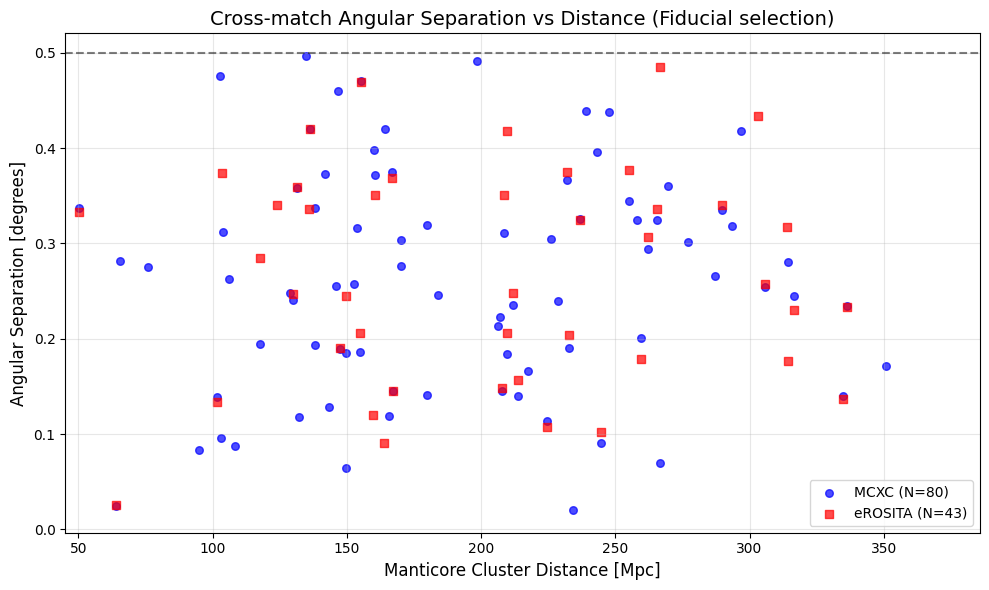

In [10]:
import matplotlib.pyplot as plt

# Create plot of angular separation vs distance for matches
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# MCXC matches
mcxc_mask = enhanced_manticore['mcxc_matched']
if np.any(mcxc_mask):
    ax.scatter(manticore_data['dist'][mcxc_mask], 
               enhanced_manticore['mcxc_ang_sep'][mcxc_mask],
               color='blue', alpha=0.7, s=30, label=f'MCXC (N={np.sum(mcxc_mask)})',
               marker='o')

# eROSITA matches  
eros_mask = enhanced_manticore['eros_matched']
if np.any(eros_mask):
    ax.scatter(manticore_data['dist'][eros_mask],
               enhanced_manticore['eros_ang_sep'][eros_mask], 
               color='red', alpha=0.7, s=30, label=f'eROSITA (N={np.sum(eros_mask)})',
               marker='s')

# Formatting
ax.set_xlabel('Manticore Cluster Distance [Mpc]', fontsize=12)
ax.set_ylabel('Angular Separation [degrees]', fontsize=12)
ax.set_title(f'Cross-match Angular Separation vs Distance ({QUALITY_SELECTION} selection)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

# Add horizontal line at tolerance
ax.axhline(ANGULAR_SEP_TOLERANCE_DEG, color='black', linestyle='--', 
           alpha=0.5, label=f'Tolerance ({ANGULAR_SEP_TOLERANCE_DEG}°)')

# Set reasonable axis limits
if np.any(mcxc_mask) or np.any(eros_mask):
    all_distances = np.concatenate([
        manticore_data['dist'][mcxc_mask] if np.any(mcxc_mask) else [],
        manticore_data['dist'][eros_mask] if np.any(eros_mask) else []
    ])
    if len(all_distances) > 0:
        ax.set_xlim(np.min(all_distances) * 0.9, np.max(all_distances) * 1.1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3756738/3819512883.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1)


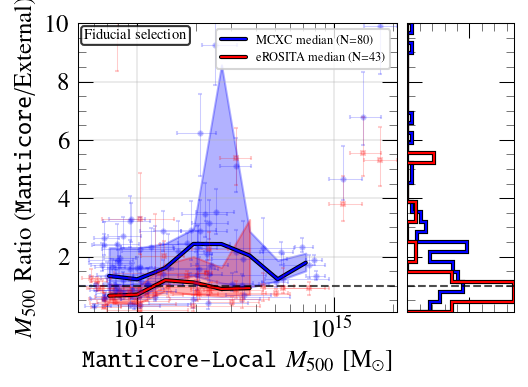


Systematic Offset Analysis (Fiducial selection):
Total matched objects: 123
Overall median ratio: 1.34
Overall mean ratio: 2.11
Standard deviation: 2.57
25th percentile: 0.82
75th percentile: 2.31
Fraction above 1.0: 63.4%
Fraction above 2.0: 32.5%

MCXC specific:
  Median ratio: 1.63
  Fraction above 1.0: 78.8%

eROSITA specific:
  Median ratio: 0.92
  Fraction above 1.0: 34.9%


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe

# Create figure with custom layout
with plt.style.context(get_mplstyle_path("mnras")):
    fig = plt.figure(figsize=(3.75, 2.5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1], wspace=0.05)
    ax_main = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1])
    
    # Create mass bins for median calculation
    mass_bins = np.logspace(13.5, 15.5, 15)
    mass_centers = np.sqrt(mass_bins[:-1] * mass_bins[1:])
    
    # Collect all ratios for histogram
    all_ratios = []
    all_colors = []
    all_labels = []
    
    # MCXC matches
    mcxc_mask = enhanced_manticore['mcxc_matched']
    if np.any(mcxc_mask):
        mcxc_ratio = enhanced_manticore['m500_manticore'][mcxc_mask] / enhanced_manticore['m500_mcxc'][mcxc_mask]
        mcxc_masses = enhanced_manticore['m500_manticore'][mcxc_mask]
        mcxc_p25 = enhanced_manticore['m500_manticore_p25'][mcxc_mask]
        mcxc_p75 = enhanced_manticore['m500_manticore_p75'][mcxc_mask]
        mcxc_external = enhanced_manticore['m500_mcxc'][mcxc_mask]
        
        # Calculate ratio uncertainties
        mcxc_ratio_lower = mcxc_p25 / mcxc_external
        mcxc_ratio_upper = mcxc_p75 / mcxc_external
        mcxc_ratio_lower_err = np.abs(mcxc_ratio - mcxc_ratio_lower)
        mcxc_ratio_upper_err = np.abs(mcxc_ratio_upper - mcxc_ratio)
        
        # Add error bars for both x and y
        mcxc_mass_lower_err = mcxc_masses - mcxc_p25
        mcxc_mass_upper_err = mcxc_p75 - mcxc_masses
        
        # Filter out invalid values
        valid_mask = np.isfinite(mcxc_ratio) & np.isfinite(mcxc_ratio_lower_err) & np.isfinite(mcxc_ratio_upper_err)
        
        ax_main.errorbar(mcxc_masses[valid_mask], mcxc_ratio[valid_mask], 
                    xerr=[mcxc_mass_lower_err[valid_mask], mcxc_mass_upper_err[valid_mask]],
                    yerr=[mcxc_ratio_lower_err[valid_mask], mcxc_ratio_upper_err[valid_mask]],
                    fmt='o', color='blue', alpha=0.2, markersize=2, capsize=1, linewidth=0.5)
        
        # Store for histogram
        all_ratios.extend(mcxc_ratio[valid_mask])
        all_colors.extend(['blue'] * np.sum(valid_mask))
        all_labels.extend(['MCXC'] * np.sum(valid_mask))
        
        # Calculate binned statistics
        mcxc_medians = []
        mcxc_p16 = []
        mcxc_p84 = []
        valid_centers = []
        
        for i in range(len(mass_bins)-1):
            in_bin = (mcxc_masses >= mass_bins[i]) & (mcxc_masses < mass_bins[i+1])
            if np.sum(in_bin) >= 3:
                bin_ratios = mcxc_ratio[in_bin]
                mcxc_medians.append(np.median(bin_ratios))
                mcxc_p16.append(np.percentile(bin_ratios, 16))
                mcxc_p84.append(np.percentile(bin_ratios, 84))
                valid_centers.append(mass_centers[i])
        
        if len(mcxc_medians) > 0:
            mcxc_medians = np.array(mcxc_medians)
            mcxc_p16 = np.array(mcxc_p16)
            mcxc_p84 = np.array(mcxc_p84)
            valid_centers = np.array(valid_centers)
            
            ax_main.fill_between(valid_centers, mcxc_p16, mcxc_p84, 
                            color='blue', alpha=0.3)
            line1 = ax_main.plot(valid_centers, mcxc_medians, color='blue', linewidth=1, 
                    solid_capstyle='round', label=f'MCXC median (N={np.sum(mcxc_mask)})')
            line1[0].set_path_effects([pe.Stroke(linewidth=2, foreground='black'), pe.Normal()])
    
    # eROSITA matches  
    eros_mask = enhanced_manticore['eros_matched']
    if np.any(eros_mask):
        eros_ratio = enhanced_manticore['m500_manticore'][eros_mask] / enhanced_manticore['m500_erosita'][eros_mask]
        eros_masses = enhanced_manticore['m500_manticore'][eros_mask]
        eros_p25 = enhanced_manticore['m500_manticore_p25'][eros_mask]
        eros_p75 = enhanced_manticore['m500_manticore_p75'][eros_mask]
        eros_external = enhanced_manticore['m500_erosita'][eros_mask]
        
        # Calculate ratio uncertainties
        eros_ratio_lower = eros_p25 / eros_external
        eros_ratio_upper = eros_p75 / eros_external
        eros_ratio_lower_err = np.abs(eros_ratio - eros_ratio_lower)
        eros_ratio_upper_err = np.abs(eros_ratio_upper - eros_ratio)
        
        # Add error bars for both x and y
        eros_mass_lower_err = eros_masses - eros_p25
        eros_mass_upper_err = eros_p75 - eros_masses
        
        # Filter out invalid values
        valid_mask = np.isfinite(eros_ratio) & np.isfinite(eros_ratio_lower_err) & np.isfinite(eros_ratio_upper_err)
        
        ax_main.errorbar(eros_masses[valid_mask], eros_ratio[valid_mask],
                    xerr=[eros_mass_lower_err[valid_mask], eros_mass_upper_err[valid_mask]],
                    yerr=[eros_ratio_lower_err[valid_mask], eros_ratio_upper_err[valid_mask]],
                    fmt='s', color='red', alpha=0.2, markersize=2, capsize=1, linewidth=0.5)
        
        # Store for histogram
        all_ratios.extend(eros_ratio[valid_mask])
        all_colors.extend(['red'] * np.sum(valid_mask))
        all_labels.extend(['eROSITA'] * np.sum(valid_mask))
        
        # Calculate binned statistics
        eros_medians = []
        eros_p16 = []
        eros_p84 = []
        valid_centers_eros = []
        
        for i in range(len(mass_bins)-1):
            in_bin = (eros_masses >= mass_bins[i]) & (eros_masses < mass_bins[i+1])
            if np.sum(in_bin) >= 3:
                bin_ratios = eros_ratio[in_bin]
                eros_medians.append(np.median(bin_ratios))
                eros_p16.append(np.percentile(bin_ratios, 16))
                eros_p84.append(np.percentile(bin_ratios, 84))
                valid_centers_eros.append(mass_centers[i])
        
        if len(eros_medians) > 0:
            eros_medians = np.array(eros_medians)
            eros_p16 = np.array(eros_p16)
            eros_p84 = np.array(eros_p84)
            valid_centers_eros = np.array(valid_centers_eros)
            
            ax_main.fill_between(valid_centers_eros, eros_p16, eros_p84,
                            color='red', alpha=0.3)
            line2 = ax_main.plot(valid_centers_eros, eros_medians, color='red', linewidth=1,
                    solid_capstyle='round', label=f'eROSITA median (N={np.sum(eros_mask)})')
            line2[0].set_path_effects([pe.Stroke(linewidth=2, foreground='black'), pe.Normal()])
    
    # Format main plot
    ax_main.set_xlabel(r'$\texttt{Manticore-Local}$ $M_{\mathrm{500}}$ [M$_{\odot}$]')
    ax_main.set_ylabel(r'$M_{\mathrm{500}}$ Ratio ($\texttt{Manticore}$/External)')
    ax_main.set_xscale('log')
    ax_main.grid(True, alpha=0.3)
    ax_main.set_ylim(0.1, 10)
    ax_main.legend(fontsize=6)
    ax_main.axhline(1.0, color='black', linestyle='--', alpha=0.7, linewidth=1)
    
    # Add quality selection annotation
    ax_main.text(0.02, 0.98, f'{QUALITY_SELECTION} selection', transform=ax_main.transAxes,
                fontsize=7, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    # Create histogram
    all_ratios = np.array(all_ratios)
    all_labels = np.array(all_labels)
    
    # Separate data by catalog
    mcxc_ratios = all_ratios[all_labels == 'MCXC']
    eros_ratios = all_ratios[all_labels == 'eROSITA']
    
    # Plot histograms
    bins = np.linspace(0.1, 10, 30)
    if len(mcxc_ratios) > 0:
        n1, bins1, patches1 = ax_hist.hist(mcxc_ratios, bins=bins, orientation='horizontal', histtype='step',
                                           color='blue', linewidth=1, label=f'MCXC (N={len(mcxc_ratios)})', density=True)
        for patch in patches1:
            patch.set_path_effects([pe.Stroke(linewidth=2, foreground='black'), pe.Normal()])
    
    if len(eros_ratios) > 0:
        n2, bins2, patches2 = ax_hist.hist(eros_ratios, bins=bins, orientation='horizontal', histtype='step',
                                           color='red', linewidth=1, label=f'eROSITA (N={len(eros_ratios)})', density=True)
        for patch in patches2:
            patch.set_path_effects([pe.Stroke(linewidth=2, foreground='black'), pe.Normal()])
    
    # Format histogram
    ax_hist.axhline(1.0, color='black', linestyle='--', alpha=0.7, linewidth=1)
    ax_hist.set_ylim(0.1, 10)
    ax_hist.set_ylabel('')
    ax_hist.set_xticklabels([])
    ax_hist.set_yticklabels([])
    
    plt.tight_layout(pad=0.1)
    plt.savefig(f"./plots/mass_ratio_external_{QUALITY_SELECTION.lower()}.pdf")
    plt.show()

# Print numerical summary
print(f"\nSystematic Offset Analysis ({QUALITY_SELECTION} selection):")
print("="*50)
if len(all_ratios) > 0:
    print(f"Total matched objects: {len(all_ratios)}")
    print(f"Overall median ratio: {np.median(all_ratios):.2f}")
    print(f"Overall mean ratio: {np.mean(all_ratios):.2f}")
    print(f"Standard deviation: {np.std(all_ratios):.2f}")
    print(f"25th percentile: {np.percentile(all_ratios, 25):.2f}")
    print(f"75th percentile: {np.percentile(all_ratios, 75):.2f}")
    print(f"Fraction above 1.0: {np.sum(all_ratios > 1.0) / len(all_ratios) * 100:.1f}%")
    print(f"Fraction above 2.0: {np.sum(all_ratios > 2.0) / len(all_ratios) * 100:.1f}%")

if len(mcxc_ratios) > 0:
    print(f"\nMCXC specific:")
    print(f"  Median ratio: {np.median(mcxc_ratios):.2f}")
    print(f"  Fraction above 1.0: {np.sum(mcxc_ratios > 1.0) / len(mcxc_ratios) * 100:.1f}%")

if len(eros_ratios) > 0:
    print(f"\neROSITA specific:")
    print(f"  Median ratio: {np.median(eros_ratios):.2f}")
    print(f"  Fraction above 1.0: {np.sum(eros_ratios > 1.0) / len(eros_ratios) * 100:.1f}%")

In [12]:
# Cell: Diagnostic of top 5 most massive Manticore halos and their potential matches

# Get indices of top 5 most massive Manticore halos
top5_indices = np.argsort(manticore_data['m500'])[-5:][::-1]

# Extended search radius for diagnostics (larger than matching tolerance)
DIAGNOSTIC_ANGULAR_RADIUS = 2.0  # degrees
DIAGNOSTIC_REDSHIFT_RANGE = 0.02

print("="*100)
print(f"DIAGNOSTIC: TOP 5 MOST MASSIVE MANTICORE HALOS ({QUALITY_SELECTION} selection)")
print("="*100)

for rank, idx in enumerate(top5_indices, 1):
    print(f"\n{'='*80}")
    print(f"RANK {rank}: Manticore Association {manticore_data['association_id'][idx]} (Index {idx})")
    print(f"{'='*80}")
    
    # Manticore cluster info
    manti_l = manticore_data['gal_l'][idx]
    manti_b = manticore_data['gal_b'][idx]
    manti_z = manticore_data['z'][idx]
    manti_m500 = manticore_data['m500'][idx]
    manti_m500_p25 = manticore_data['m500_p25'][idx]
    manti_m500_p75 = manticore_data['m500_p75'][idx]
    
    print(f"\nMANTICORE CLUSTER:")
    print(f"   Position: l={manti_l:.3f} deg, b={manti_b:.3f} deg")
    print(f"   Redshift: z={manti_z:.4f}")
    print(f"   M500: {manti_m500:.2e} Msol [{manti_m500_p25:.2e} - {manti_m500_p75:.2e}]")
    print(f"   N_members: {manticore_data['cluster_size'][idx]}")
    
    # Find ALL MCXC clusters within diagnostic radius
    print(f"\nNEARBY MCXC CLUSTERS (within {DIAGNOSTIC_ANGULAR_RADIUS} deg and dz<{DIAGNOSTIC_REDSHIFT_RANGE}):")
    
    # Calculate angular separations to all MCXC clusters
    mcxc_ang_seps_all = vectorized_angular_separation_deg(
        np.array([manti_l]), np.array([manti_b]),
        mcxc_data['gal_l'], mcxc_data['gal_b']
    )[0]
    
    mcxc_z_diffs_all = np.abs(mcxc_data['z'] - manti_z)
    
    # Find all within diagnostic window
    mcxc_nearby = (mcxc_ang_seps_all <= DIAGNOSTIC_ANGULAR_RADIUS) & (mcxc_z_diffs_all <= DIAGNOSTIC_REDSHIFT_RANGE)
    mcxc_nearby_indices = np.where(mcxc_nearby)[0]
    
    if len(mcxc_nearby_indices) > 0:
        # Sort by angular separation
        sorted_idx = np.argsort(mcxc_ang_seps_all[mcxc_nearby_indices])
        mcxc_nearby_indices = mcxc_nearby_indices[sorted_idx]
        
        for i, mcxc_idx in enumerate(mcxc_nearby_indices[:10]):  # Show up to 10
            is_match = mcxc_idx == mcxc_match_indices[idx] if mcxc_matched[idx] else False
            match_marker = " << SELECTED MATCH" if is_match else ""
            in_tolerance = (mcxc_ang_seps_all[mcxc_idx] <= ANGULAR_SEP_TOLERANCE_DEG and 
                          mcxc_z_diffs_all[mcxc_idx] <= REDSHIFT_TOLERANCE)
            tolerance_marker = " [OK]" if in_tolerance else " [OUT]"
            
            mass_ratio = manti_m500 / mcxc_data['m500'][mcxc_idx]
            
            name = mcxc_data['name'][mcxc_idx]
            if isinstance(name, bytes):
                name = name.decode()
            
            print(f"   {i+1}. {name}")
            print(f"      dtheta={mcxc_ang_seps_all[mcxc_idx]:.3f} deg, dz={mcxc_z_diffs_all[mcxc_idx]:.4f}{tolerance_marker}")
            print(f"      M500={mcxc_data['m500'][mcxc_idx]:.2e} Msol (ratio={mass_ratio:.2f}){match_marker}")
    else:
        print("   No MCXC clusters found in extended search window")
    
    # Find ALL eROSITA clusters within diagnostic radius
    print(f"\nNEARBY eROSITA CLUSTERS (within {DIAGNOSTIC_ANGULAR_RADIUS} deg and dz<{DIAGNOSTIC_REDSHIFT_RANGE}):")
    
    # Calculate angular separations to all eROSITA clusters
    eros_ang_seps_all = vectorized_angular_separation_deg(
        np.array([manti_l]), np.array([manti_b]),
        eros_data['gal_l'], eros_data['gal_b']
    )[0]
    
    eros_z_diffs_all = np.abs(eros_data['z'] - manti_z)
    
    # Find all within diagnostic window
    eros_nearby = (eros_ang_seps_all <= DIAGNOSTIC_ANGULAR_RADIUS) & (eros_z_diffs_all <= DIAGNOSTIC_REDSHIFT_RANGE)
    eros_nearby_indices = np.where(eros_nearby)[0]
    
    if len(eros_nearby_indices) > 0:
        # Sort by angular separation
        sorted_idx = np.argsort(eros_ang_seps_all[eros_nearby_indices])
        eros_nearby_indices = eros_nearby_indices[sorted_idx]
        
        for i, eros_idx in enumerate(eros_nearby_indices[:10]):  # Show up to 10
            is_match = eros_idx == eros_match_indices[idx] if eros_matched[idx] else False
            match_marker = " << SELECTED MATCH" if is_match else ""
            in_tolerance = (eros_ang_seps_all[eros_idx] <= ANGULAR_SEP_TOLERANCE_DEG and 
                          eros_z_diffs_all[eros_idx] <= REDSHIFT_TOLERANCE)
            tolerance_marker = " [OK]" if in_tolerance else " [OUT]"
            
            mass_ratio = manti_m500 / eros_data['m500'][eros_idx]
            
            print(f"   {i+1}. Cluster at l={eros_data['gal_l'][eros_idx]:.3f} deg, b={eros_data['gal_b'][eros_idx]:.3f} deg")
            print(f"      dtheta={eros_ang_seps_all[eros_idx]:.3f} deg, dz={eros_z_diffs_all[eros_idx]:.4f}{tolerance_marker}")
            print(f"      M500={eros_data['m500'][eros_idx]:.2e} Msol (ratio={mass_ratio:.2f}){match_marker}")
    else:
        print("   No eROSITA clusters found in extended search window")
    
    # Summary for this cluster
    print(f"\nMATCHING SUMMARY:")
    if mcxc_matched[idx]:
        matched_mcxc_m500 = mcxc_data['m500'][mcxc_match_indices[idx]]
        print(f"   MCXC match: M500 ratio = {manti_m500/matched_mcxc_m500:.2f}")
    else:
        print(f"   MCXC: No match within tolerance")
        
    if eros_matched[idx]:
        matched_eros_m500 = eros_data['m500'][eros_match_indices[idx]]
        print(f"   eROSITA match: M500 ratio = {manti_m500/matched_eros_m500:.2f}")
    else:
        print(f"   eROSITA: No match within tolerance")
    
    # Check if there are better mass-matched candidates
    if len(mcxc_nearby_indices) > 0:
        mass_ratios_mcxc = manti_m500 / mcxc_data['m500'][mcxc_nearby_indices]
        best_mass_match_idx = mcxc_nearby_indices[np.argmin(np.abs(mass_ratios_mcxc - 1.0))]
        if not mcxc_matched[idx] or best_mass_match_idx != mcxc_match_indices[idx]:
            name = mcxc_data['name'][best_mass_match_idx]
            if isinstance(name, bytes):
                name = name.decode()
            print(f"\n   Note: Better MCXC mass match available:")
            print(f"      {name}")
            print(f"      dtheta={mcxc_ang_seps_all[best_mass_match_idx]:.3f} deg, ratio={manti_m500/mcxc_data['m500'][best_mass_match_idx]:.2f}")

print("\n" + "="*100)
print("LEGEND: [OK] = within matching tolerance, [OUT] = outside tolerance")

DIAGNOSTIC: TOP 5 MOST MASSIVE MANTICORE HALOS (Fiducial selection)

RANK 1: Manticore Association 0 (Index 0)

MANTICORE CLUSTER:
   Position: l=312.243 deg, b=30.516 deg
   Redshift: z=0.0488
   M500: 1.71e+15 Msol [1.43e+15 - 2.09e+15]
   N_members: 80

NEARBY MCXC CLUSTERS (within 2.0 deg and dz<0.02):
   1. MCXC J1329.7-3136+A3558
      dtheta=0.140 deg, dz=0.0000 [OK]
      M500=1.73e+14 Msol (ratio=9.90) << SELECTED MATCH
   2. MCXC J1327.9-3130+A3558
      dtheta=0.305 deg, dz=0.0008 [OK]
      M500=3.93e+14 Msol (ratio=4.36)
   3. MCXC J1331.5-3148+A3558
      dtheta=0.529 deg, dz=0.0040 [OUT]
      M500=8.54e+13 Msol (ratio=20.04)
   4. MCXC J1333.6-3139+A3562
      dtheta=0.949 deg, dz=0.0002 [OUT]
      M500=2.37e+14 Msol (ratio=7.23)
   5. MCXC J1323.4-3142
      dtheta=1.213 deg, dz=0.0008 [OUT]
      M500=8.04e+13 Msol (ratio=21.31)
   6. MCXC J1329.8-3310
      dtheta=1.507 deg, dz=0.0023 [OUT]
      M500=1.61e+13 Msol (ratio=106.57)
   7. MCXC J1332.3-3308+A3560
      